In [94]:

import cmdstanpy
import numpy as np
import pandas as pd 
from scipy.special import expit  # inverse logit

In [95]:
df = pd.read_csv("forstmann.csv")

df["correct"] = df.apply(lambda row: 1 if row["S"] == row["R"] else 0,axis = 1)
df['participant_id'], participant_labels = pd.factorize(df['subjects'])
df['participant_id'] += 1  
df = df[df["participant_id"]<10]
sat_map = {"speed":1,"neutral":2,"accuracy":3}
df["sat_int"] = df["E"].map(sat_map)
df["pc"] = (df["participant_id"]-1)*3 + df["sat_int"]
df

,subjects,E,S,R,rt,correct,participant_id,sat_int,pc
0,as1t,accuracy,right,right,0.4319,1,1,3,3
1,as1t,speed,right,right,0.5015,1,1,1,1
2,as1t,speed,left,left,0.3104,1,1,1,1
3,as1t,accuracy,right,right,0.4809,1,1,3,3
4,as1t,accuracy,left,left,0.3415,1,1,3,3
...,...,...,...,...,...,...,...,...,...
7575,kmat,neutral,right,right,0.4633,1,9,2,26
7576,kmat,neutral,left,left,0.4212,1,9,2,26
7577,kmat,neutral,left,right,0.3950,0,9,2,26
7578,kmat,speed,right,right,0.4496,1,9,1,25


In [96]:
max_rt = (df.groupby(['participant_id','sat_int'])["rt"].max())
max_rt

participant_id  sat_int
1               1          0.7979
                2          1.1555
                3          0.9912
2               1          0.6489
                2          1.1242
                3          1.3960
3               1          0.8129
                2          1.4322
                3          1.4769
4               1          0.7022
                2          0.8110
                3          1.0007
5               1          0.6481
                2          0.9952
                3          1.4364
6               1          0.9039
                2          0.9092
                3          1.3001
7               1          1.2651
                2          1.2043
                3          1.4077
8               1          1.2592
                2          1.3809
                3          1.3834
9               1          1.3234
                2          1.1941
                3          1.2196
Name: rt, dtype: float64

In [97]:
N_correct = len(df[df["correct"] == 1])
N_false = len(df[df["correct"] == 0])
P = 9

rt_correct = list(df[df["correct"]==1]["rt"])
rt_false = list(df[df["correct"]==0]["rt"])
pc_correct = list(df[df["correct"]==1]["pc"])
pc_false = list(df[df["correct"]==0]["pc"])

t0_hi = (
    df.groupby('pc')['rt']
    .quantile(0.05)
    .reindex(range(1, 3 * P + 1))
)
assert t0_hi.notna().all(), "some cell has zero trials in t0_hi"

max_rt = (
    df.groupby('pc')['rt']
    .max()
    .reindex(range(1, 3 * P + 1))  # was groupby(['participant_id','sat_int']) - fragile, see earlier note
)
assert max_rt.notna().all(), "some cell has zero trials in max_rt"

print(N_correct, N_false, rt_false)

data = {
    "N_correct": N_correct, "N_false": N_false, "P": P,
    "rt_correct": rt_correct, "rt_false": rt_false,
    "pc_correct": pc_correct, "pc_false": pc_false,
    "max_rt": max_rt.to_numpy(), "t0_hi": t0_hi.to_numpy(),
}

from cmdstanpy import CmdStanModel

model = CmdStanModel(stan_file='SRDM_hierarchical_collapsed_smoothed_v2.stan')  # <- the r/p_lapse-collapsed version

6490 1090 [0.3111, 0.4118, 0.4343, 0.3286, 0.4872, 0.321, 0.4179, 0.6087, 0.3561, 0.5971, 0.4731, 0.7205, 0.4949, 0.4222, 0.3304, 0.5636, 0.2693, 0.2952, 0.3923, 0.4207, 0.3172, 0.3472, 0.4619, 0.5878, 0.4227, 0.4178, 0.7814, 0.4248, 0.4782, 0.2508, 0.3542, 0.2742, 0.4646, 0.5855, 0.4592, 0.5876, 0.4358, 0.3632, 0.5256, 0.6568, 0.6033, 0.5813, 0.3321, 0.6356, 0.3355, 0.6077, 0.6896, 0.4748, 0.4662, 0.5469, 0.4984, 0.3845, 0.4819, 0.4135, 0.4852, 0.4698, 0.4768, 0.4402, 0.6428, 0.4315, 0.6628, 0.7461, 0.4767, 0.5287, 0.6025, 0.5145, 0.8565, 0.4453, 0.5473, 0.4656, 0.4555, 0.6289, 0.3824, 0.4643, 0.485, 0.301, 0.3467, 0.4999, 0.3045, 0.5888, 0.5423, 0.4593, 0.5522, 0.4058, 0.5459, 0.4679, 0.6829, 0.4227, 0.6181, 0.4917, 0.3587, 0.3434, 0.5736, 0.388, 0.4163, 0.6115, 0.4535, 0.4528, 0.3136, 0.3105, 0.3589, 0.3007, 0.3154, 0.2692, 0.449, 0.3353, 0.3959, 0.4254, 0.4713, 0.5634, 0.3659, 0.369, 0.4745, 0.4393, 0.4981, 0.3239, 0.7392, 0.4319, 0.3065, 0.433, 0.6091, 0.3335, 0.5856, 0.4238, 0.29

In [101]:


init_values = {
    'mu_c': [0.0]*3, 'sigma_c': [0.3]*3,
    'mu_logd': [np.log(1.5)]*3, 'sigma_logd': [0.2]*3,
    'mu_logB': [0.0]*3, 'sigma_logB': [0.2]*3,
    'mu_t0_logit': [0.0]*3, 'sigma_t0_logit': [0.2]*3,
    'mu_logr': np.log(4.5), 'sigma_logr': 0.2,           # now scalars
    'mu_lapse_logit': -3.9, 'sigma_lapse_logit': 0.2,     # now scalars
    'c_z': [0.0]*(3*P), 'logd_z': [0.0]*(3*P),
    'logB_z': [0.0]*(3*P), 't0_z': [0.0]*(3*P),
    'logr_z': [0.0]*P, 'lapse_z': [0.0]*P,                # now length P
}
fit = model.sample(data=data, chains=2, parallel_chains=2, inits=init_values,
                    iter_warmup=300, iter_sampling=300, adapt_delta=0.9, metric='diag_e')

19:15:51 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

19:46:17 - cmdstanpy - INFO - CmdStan done processing.
19:46:17 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 1 had 95 divergent transitions (31.7%)
	Chain 2 had 108 divergent transitions (36.0%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.


In [99]:
sampler_vars = fit.method_variables()
print(np.mean(sampler_vars['treedepth__']), np.mean(sampler_vars['n_leapfrog__']))

6.828333333333333 169.88833333333332


In [ ]:
import matplotlib.pyplot as plt
import arviz as az
idata = az.from_cmdstanpy(fit)
print(az.summary(idata, var_names=["mu_c", "sigma_c", "mu_logd", "sigma_logd",
                               "mu_logr", "sigma_logr", "mu_logB", "sigma_logB",
                               "mu_t0_logit", "sigma_t0_logit",
                                                              "mu_lapse_logit", "sigma_lapse_logit"]))

                    mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  \
mu_c[0]           -0.488  0.120  -0.724   -0.277      0.008    0.006   
mu_c[1]           -0.019  0.111  -0.213    0.215      0.007    0.006   
mu_c[2]            0.184  0.138  -0.074    0.443      0.011    0.007   
sigma_c[0]         0.329  0.099   0.182    0.504      0.006    0.006   
sigma_c[1]         0.288  0.108   0.143    0.485      0.007    0.007   
sigma_c[2]         0.368  0.108   0.194    0.562      0.008    0.006   
mu_logd[0]         0.245  0.150  -0.025    0.536      0.011    0.009   
mu_logd[1]         0.519  0.141   0.298    0.806      0.011    0.008   
mu_logd[2]         0.608  0.124   0.421    0.868      0.008    0.008   
sigma_logd[0]      0.389  0.115   0.202    0.610      0.008    0.007   
sigma_logd[1]      0.404  0.118   0.219    0.646      0.007    0.006   
sigma_logd[2]      0.351  0.095   0.194    0.515      0.006    0.005   
mu_logr            1.982  0.096   1.771    2.130      0.007    0

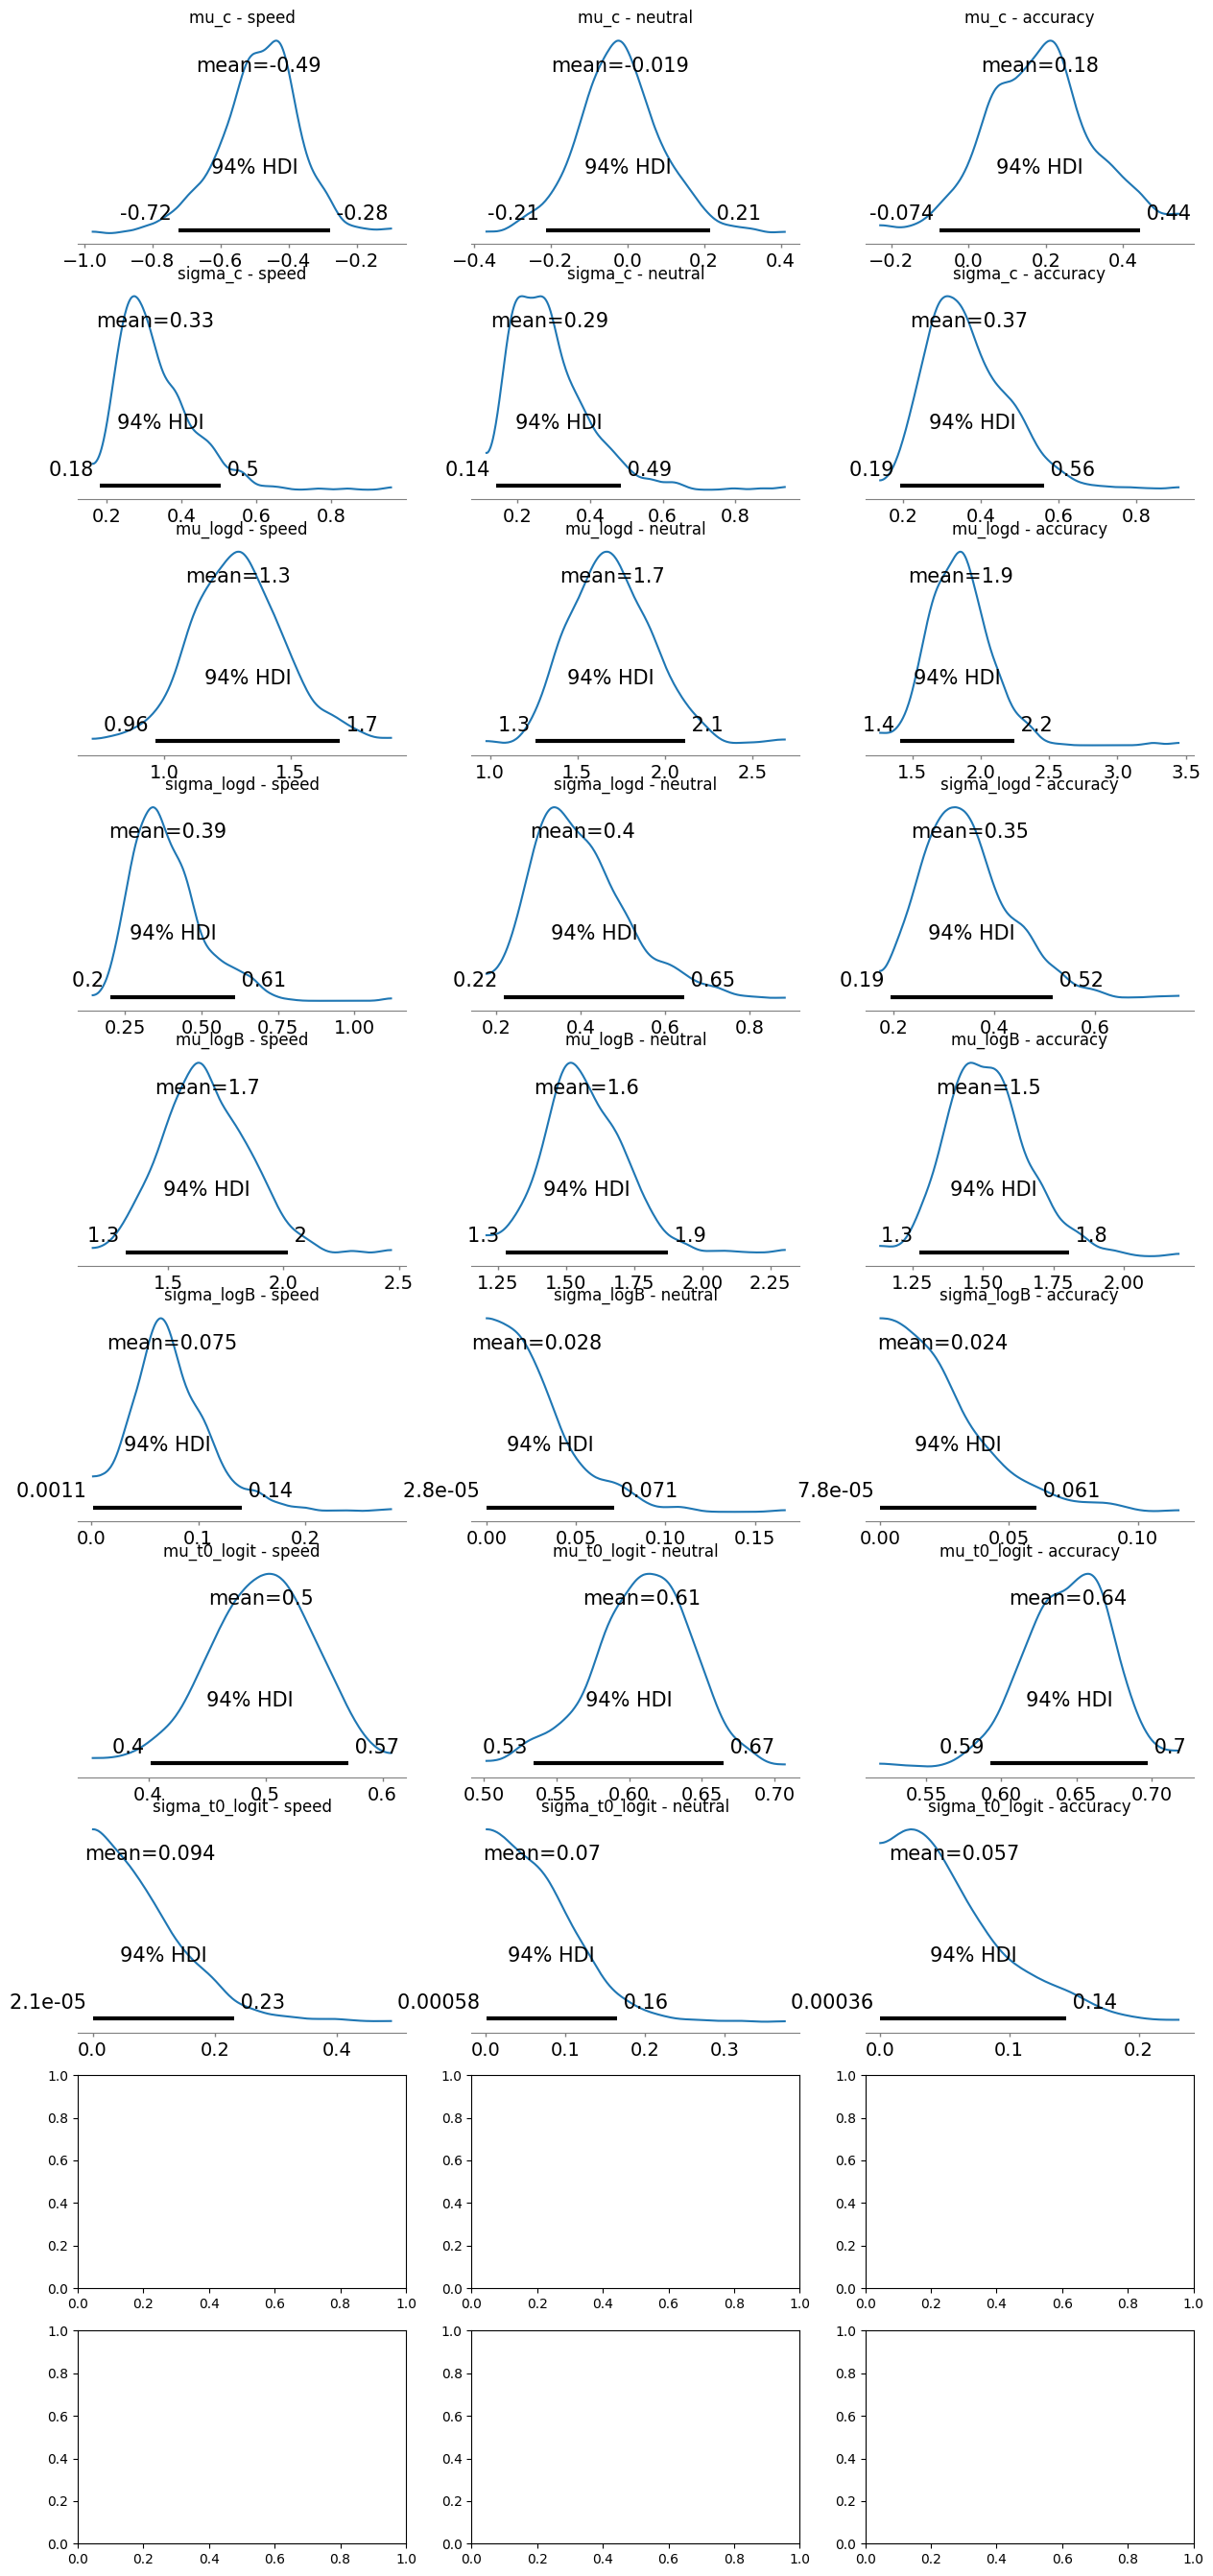

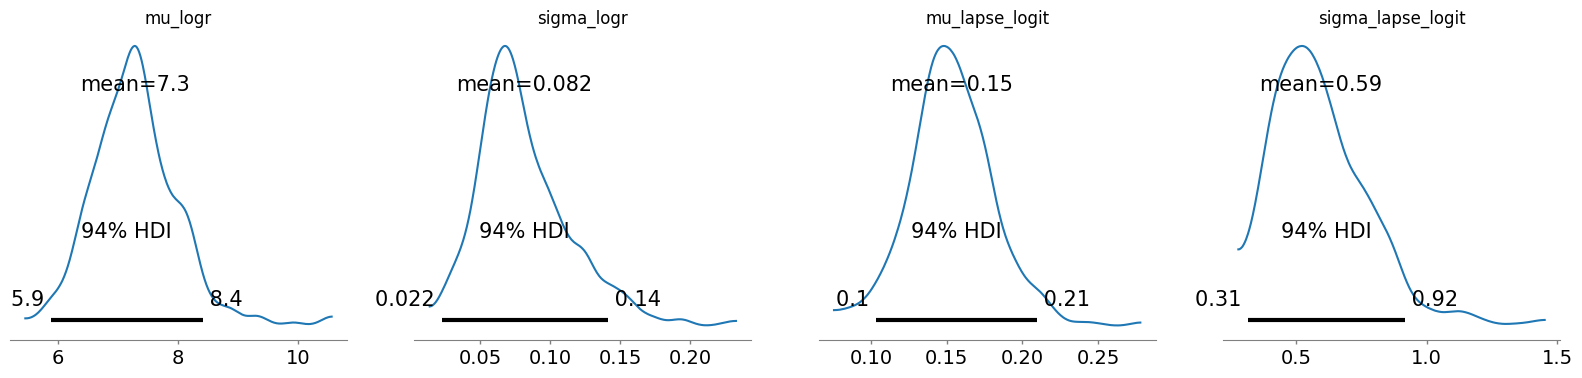

In [ ]:


cond_labels = ["speed", "neutral", "accuracy"]
hyper_pairs_percond = [
    ("mu_c", "sigma_c"), ("mu_logd", "sigma_logd"),
    ("mu_logB", "sigma_logB"), ("mu_t0_logit", "sigma_t0_logit"),
]
hyper_scalars = [("mu_logr", "sigma_logr"), ("mu_lapse_logit", "sigma_lapse_logit")]

transforms = {
    "mu_c": None,               # already natural scale (real-valued criterion)
    "sigma_c": None,
    "mu_logd": np.exp,          # -> population d' (median)
    "sigma_logd": None,         # spread on log scale - see note below
    "mu_logr": np.exp,          # -> population r (steps/sec)
    "sigma_logr": None,
    "mu_logB": np.exp,          # -> population B
    "sigma_logB": None,
    "mu_t0_logit": expit,       # -> fraction of t0_hi (still 0-1, not seconds - see note)
    "sigma_t0_logit": None,
    "mu_lapse_logit": expit,    # -> population lapse rate, 0-1
    "sigma_lapse_logit": None,
}
hyper_pairs_percond = [
    ("mu_c", "sigma_c"), ("mu_logd", "sigma_logd"),
    ("mu_logB", "sigma_logB"), ("mu_t0_logit", "sigma_t0_logit"),
]
hyper_scalars = [("mu_logr", "sigma_logr"), ("mu_lapse_logit", "sigma_lapse_logit")]

fig, axes = plt.subplots(10, 3, figsize=(15, 34))
row = 0
for mu_var, sigma_var in hyper_pairs_percond:
    for var in (mu_var, sigma_var):
        dim = f"{var}_dim_0"
        for j, cond in enumerate(cond_labels):
            az.plot_posterior(idata, var_names=[var], coords={dim: [j]},
                               transform=transforms[var], ax=axes[row, j])
            axes[row, j].set_title(f"{var} - {cond}")
        row += 1

# scalars get their own single-panel plots, no coords/loop needed
fig2, axes2 = plt.subplots(1, 4, figsize=(20, 4))
for i, var in enumerate([v for pair in hyper_scalars for v in pair]):
    az.plot_posterior(idata, var_names=[var], transform=transforms[var], ax=axes2[i])
    axes2[i].set_title(var)
plt.show()

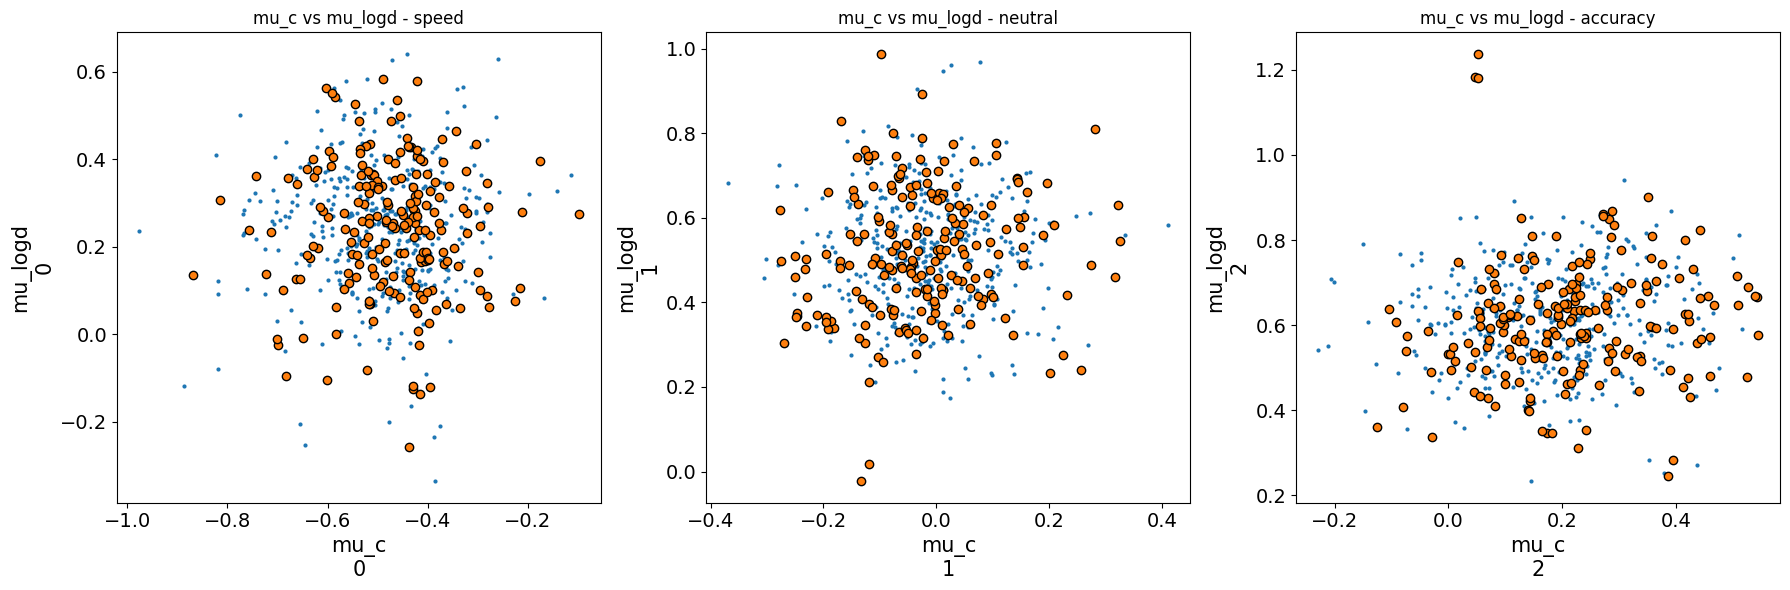

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for j, cond in enumerate(cond_labels):
    az.plot_pair(
        idata,
        var_names=["mu_c", "mu_logd"],
        coords={"mu_c_dim_0": [j], "mu_logd_dim_0": [j]},
        kind="scatter",
        divergences=True,
        ax=axes[j],
    )
    axes[j].set_title(f"mu_c vs mu_logd - {cond}")

plt.tight_layout()
plt.show()

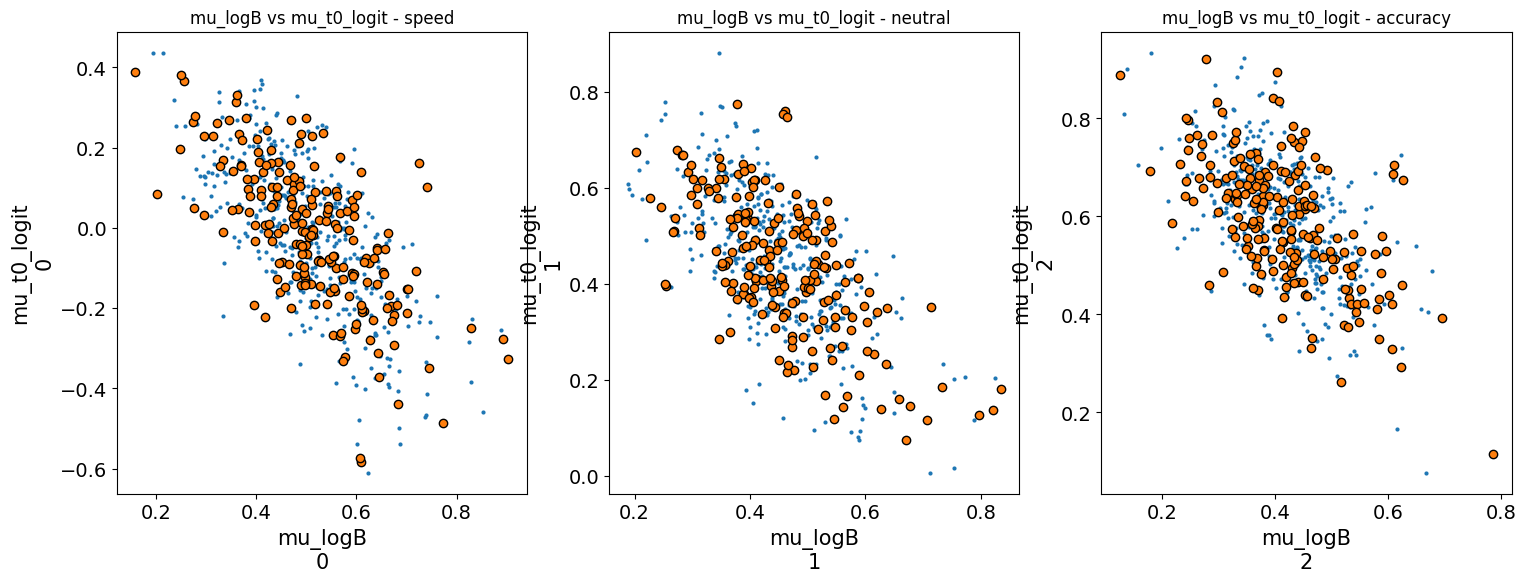

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for j, cond in enumerate(cond_labels):
    az.plot_pair(
        idata, var_names=["mu_logB", "mu_t0_logit"],
        coords={"mu_logB_dim_0": [j], "mu_t0_logit_dim_0": [j]},
        kind="scatter", divergences=True, ax=axes[j],
    )
    axes[j].set_title(f"mu_logB vs mu_t0_logit - {cond}")
plt.show()

In [ ]:
fit.diagnose()

"Checking sampler transitions treedepth.\nTreedepth satisfactory for all transitions.\n\nChecking sampler transitions for divergences.\n202 of 600 (33.67%) transitions ended with a divergence.\nThese divergent transitions indicate that HMC is not fully able to explore the posterior distribution.\nTry increasing adapt delta closer to 1.\nIf this doesn't remove all divergences, try to reparameterize the model.\n\nChecking E-BFMI - sampler transitions HMC potential energy.\nE-BFMI satisfactory.\n\nRank-normalized split effective sample size satisfactory for all parameters.\n\nThe following parameters had rank-normalized split R-hat greater than 1.01:\n  sigma_logB[2], sigma_logB[3], sigma_logr, c_z[13], c_z[22], logd_z[4], logd_z[27], logB_z[13], logB_z[16], logr_z[1], logr_z[7], c[15], B[13], t0[2], t0[9], pf[22], sigma_k[15]\nSuch high values indicate incomplete mixing and biased estimation.\nYou should consider regularizing your model with additional prior information or a more effecti

In [ ]:
print(idata.sample_stats["diverging"].sum().item(), "of", idata.sample_stats["diverging"].size)

202 of 600


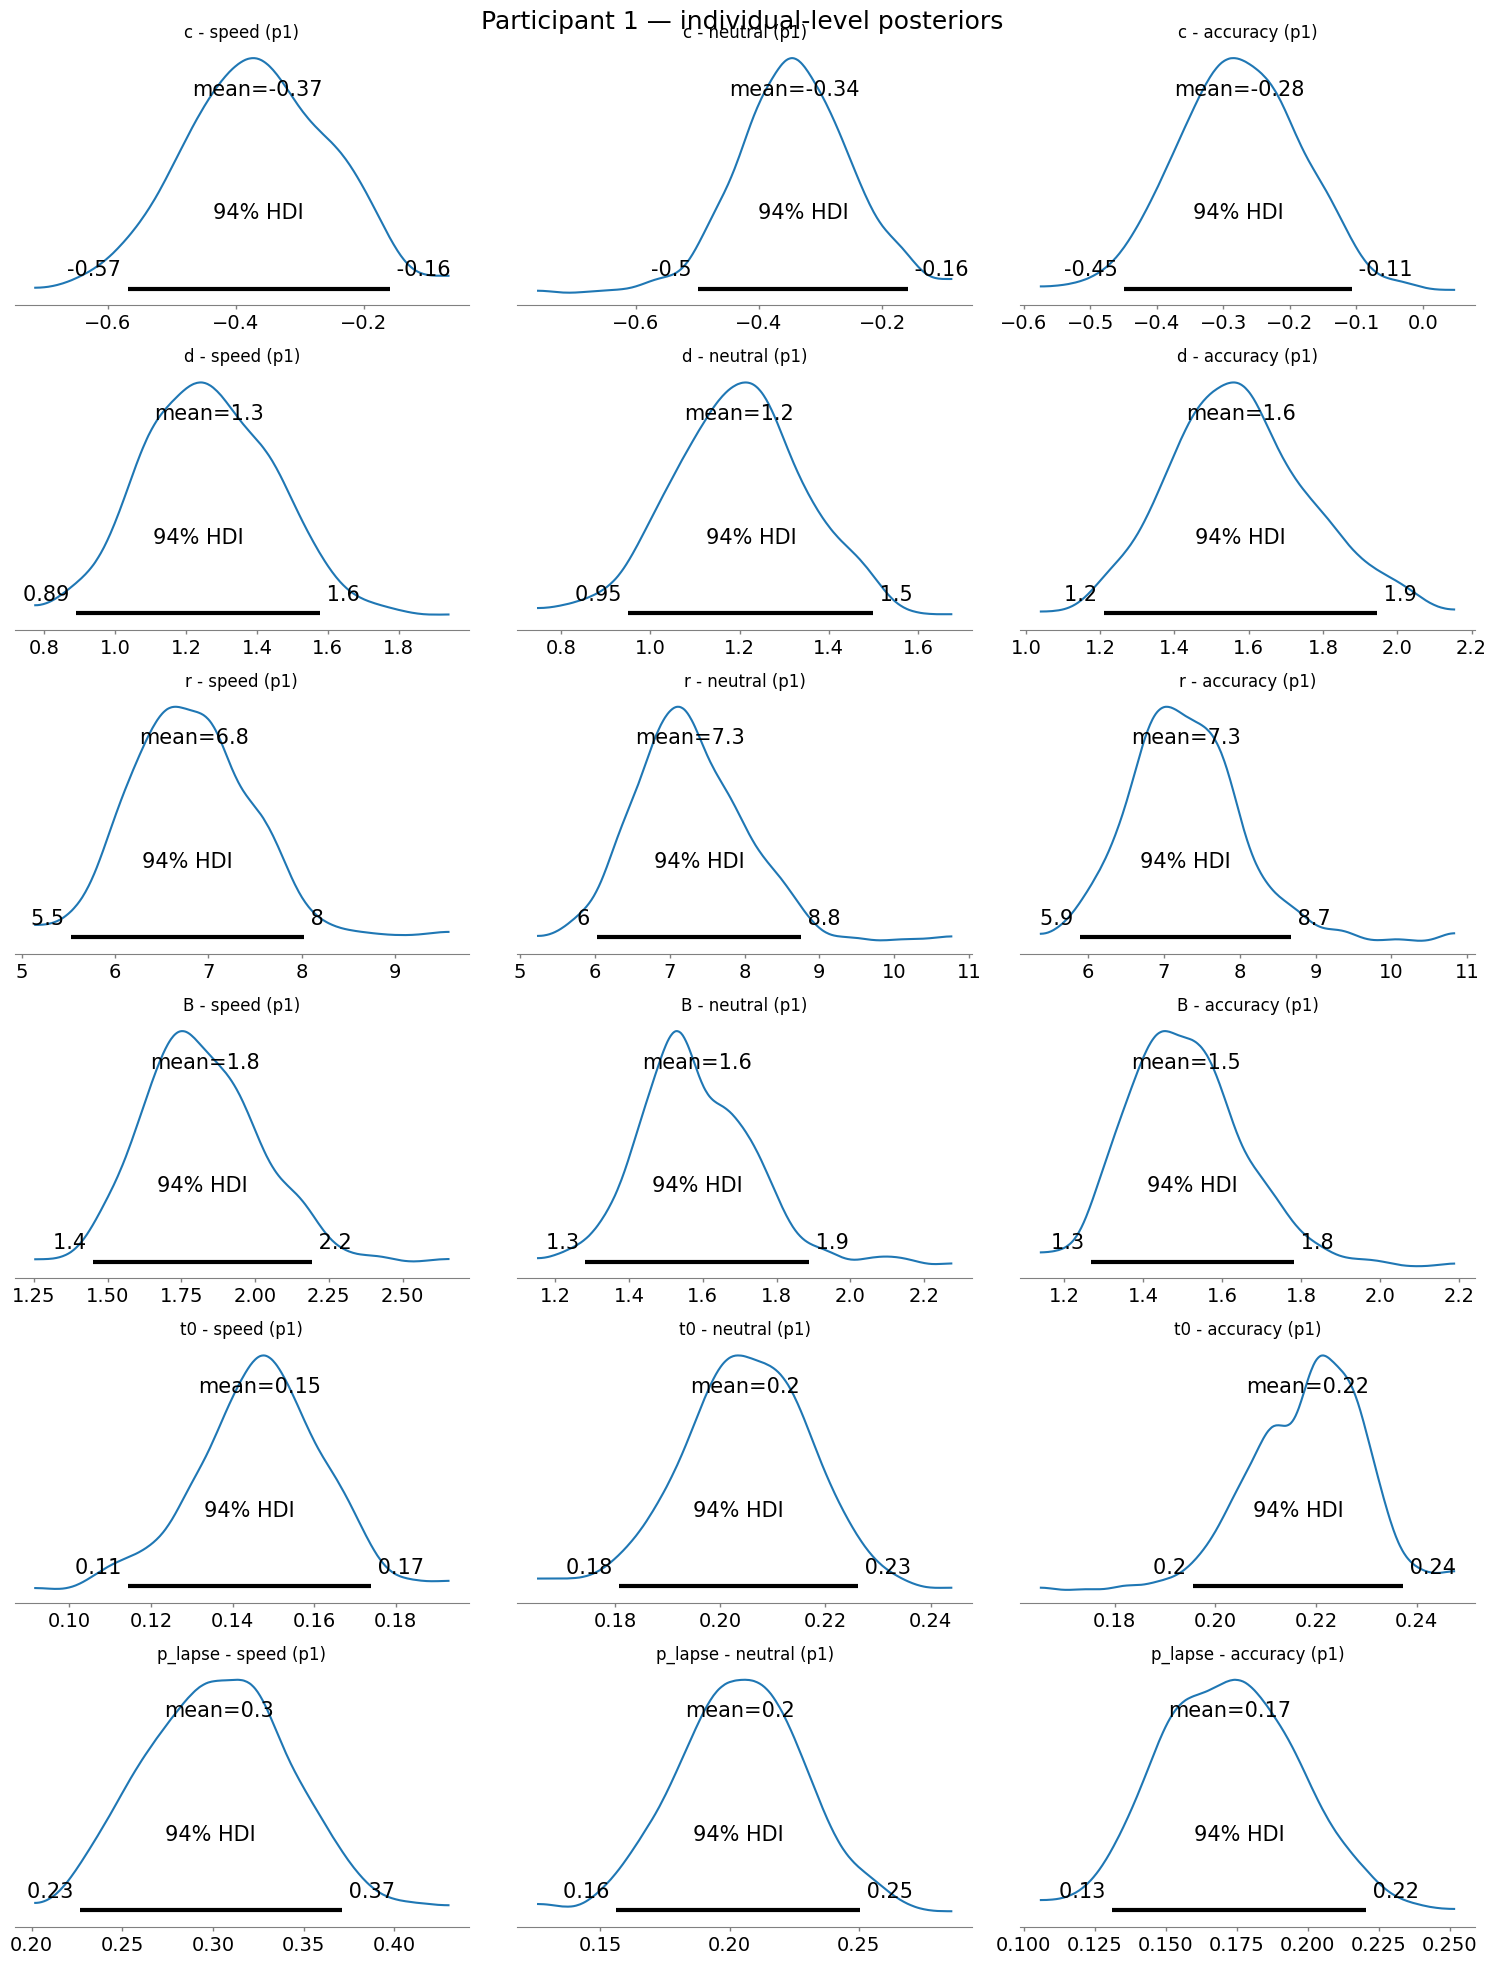

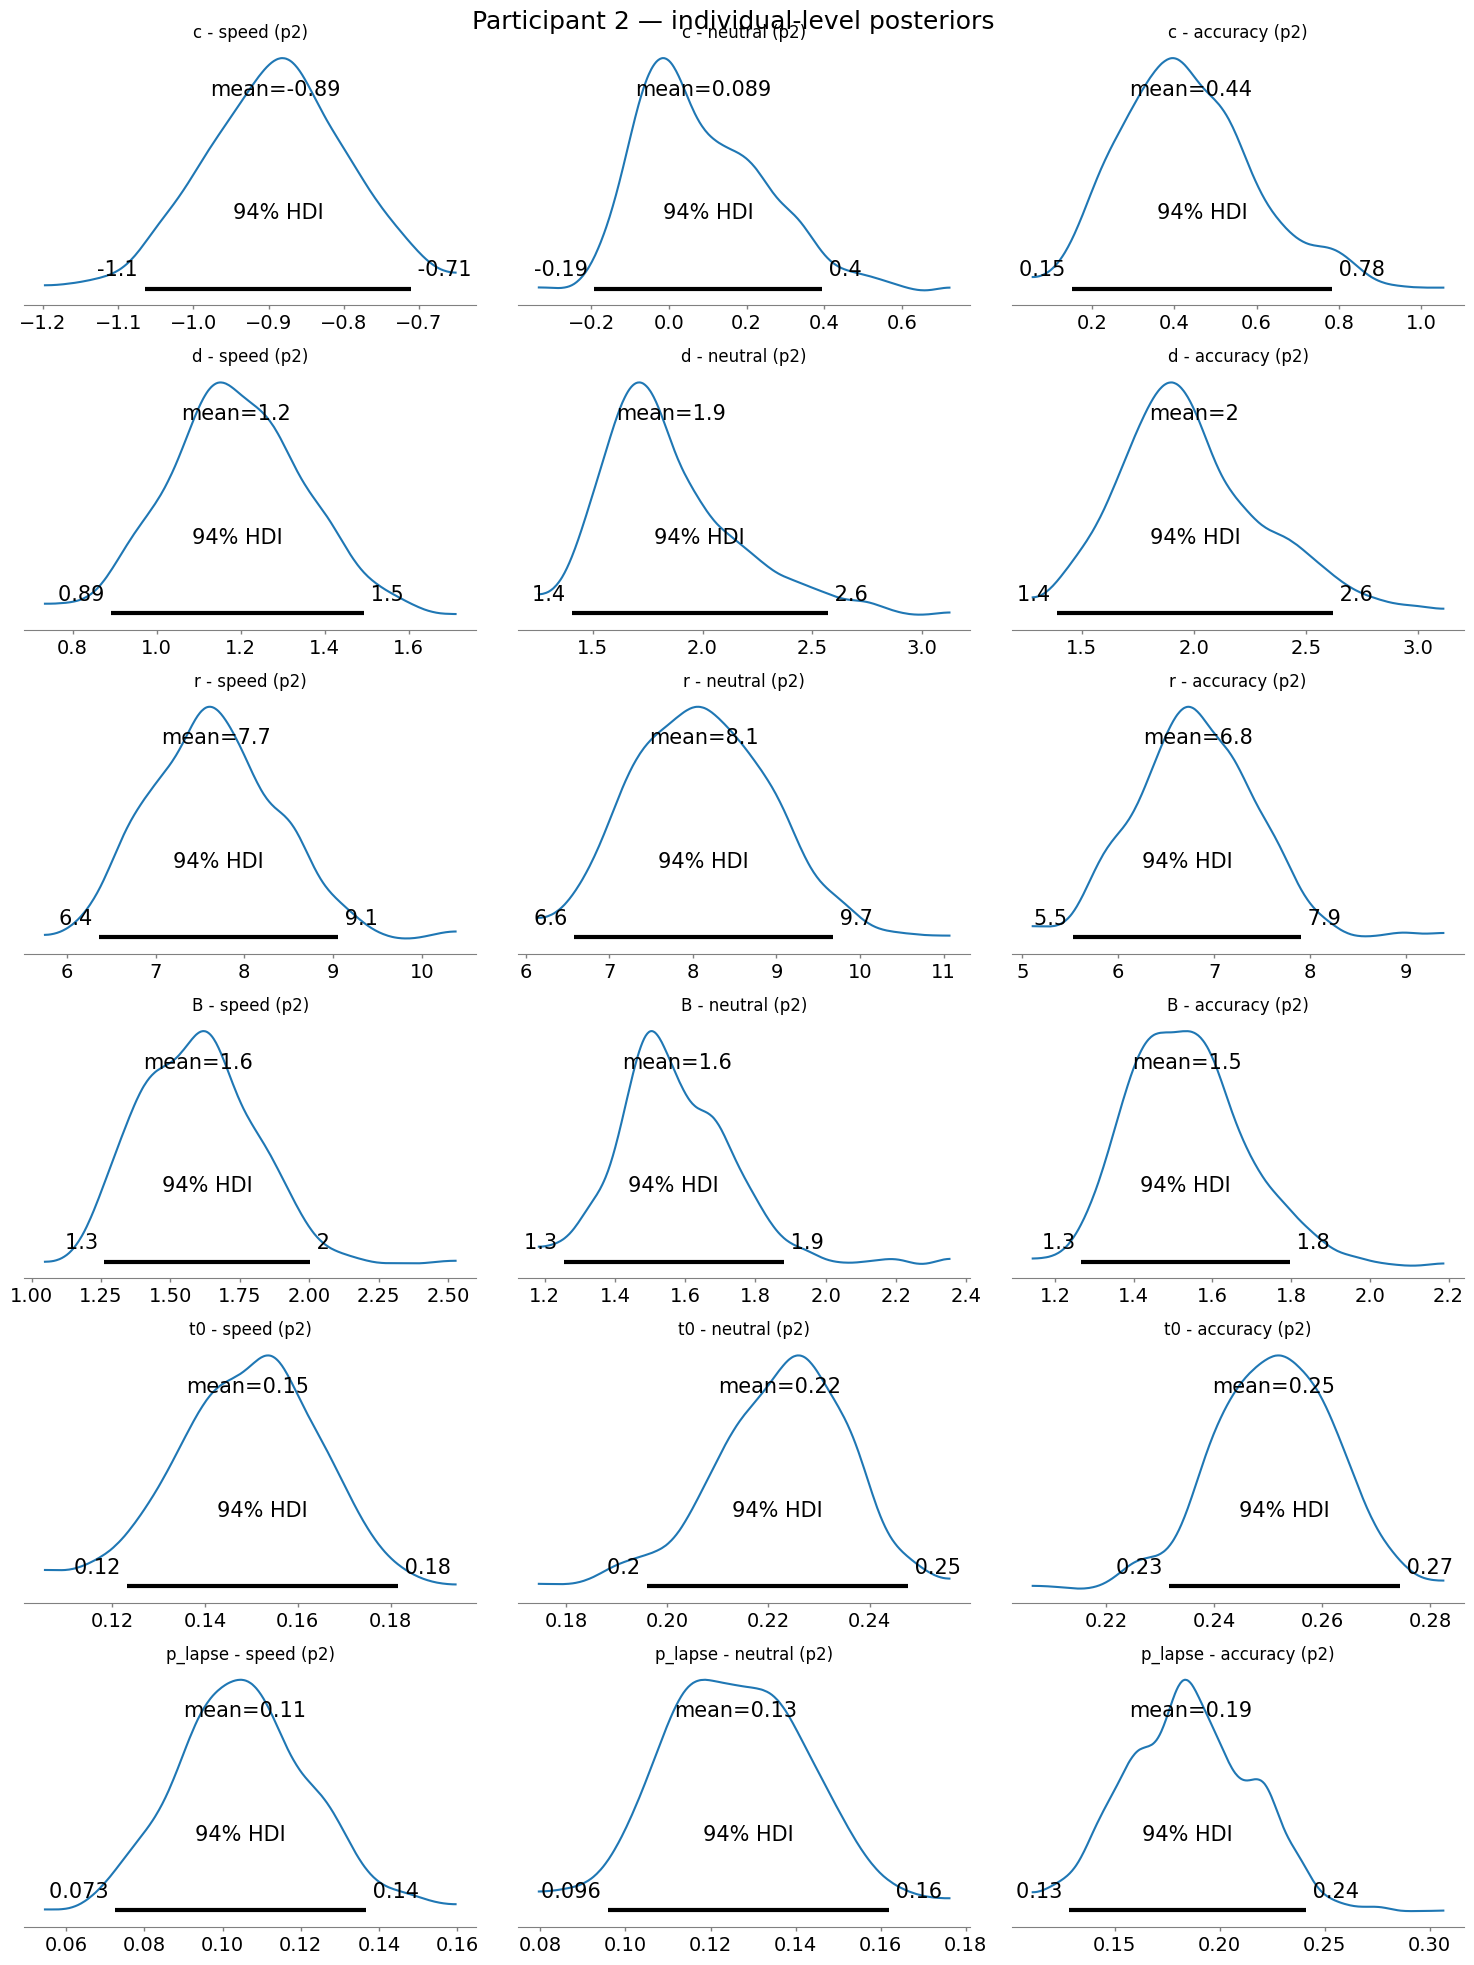

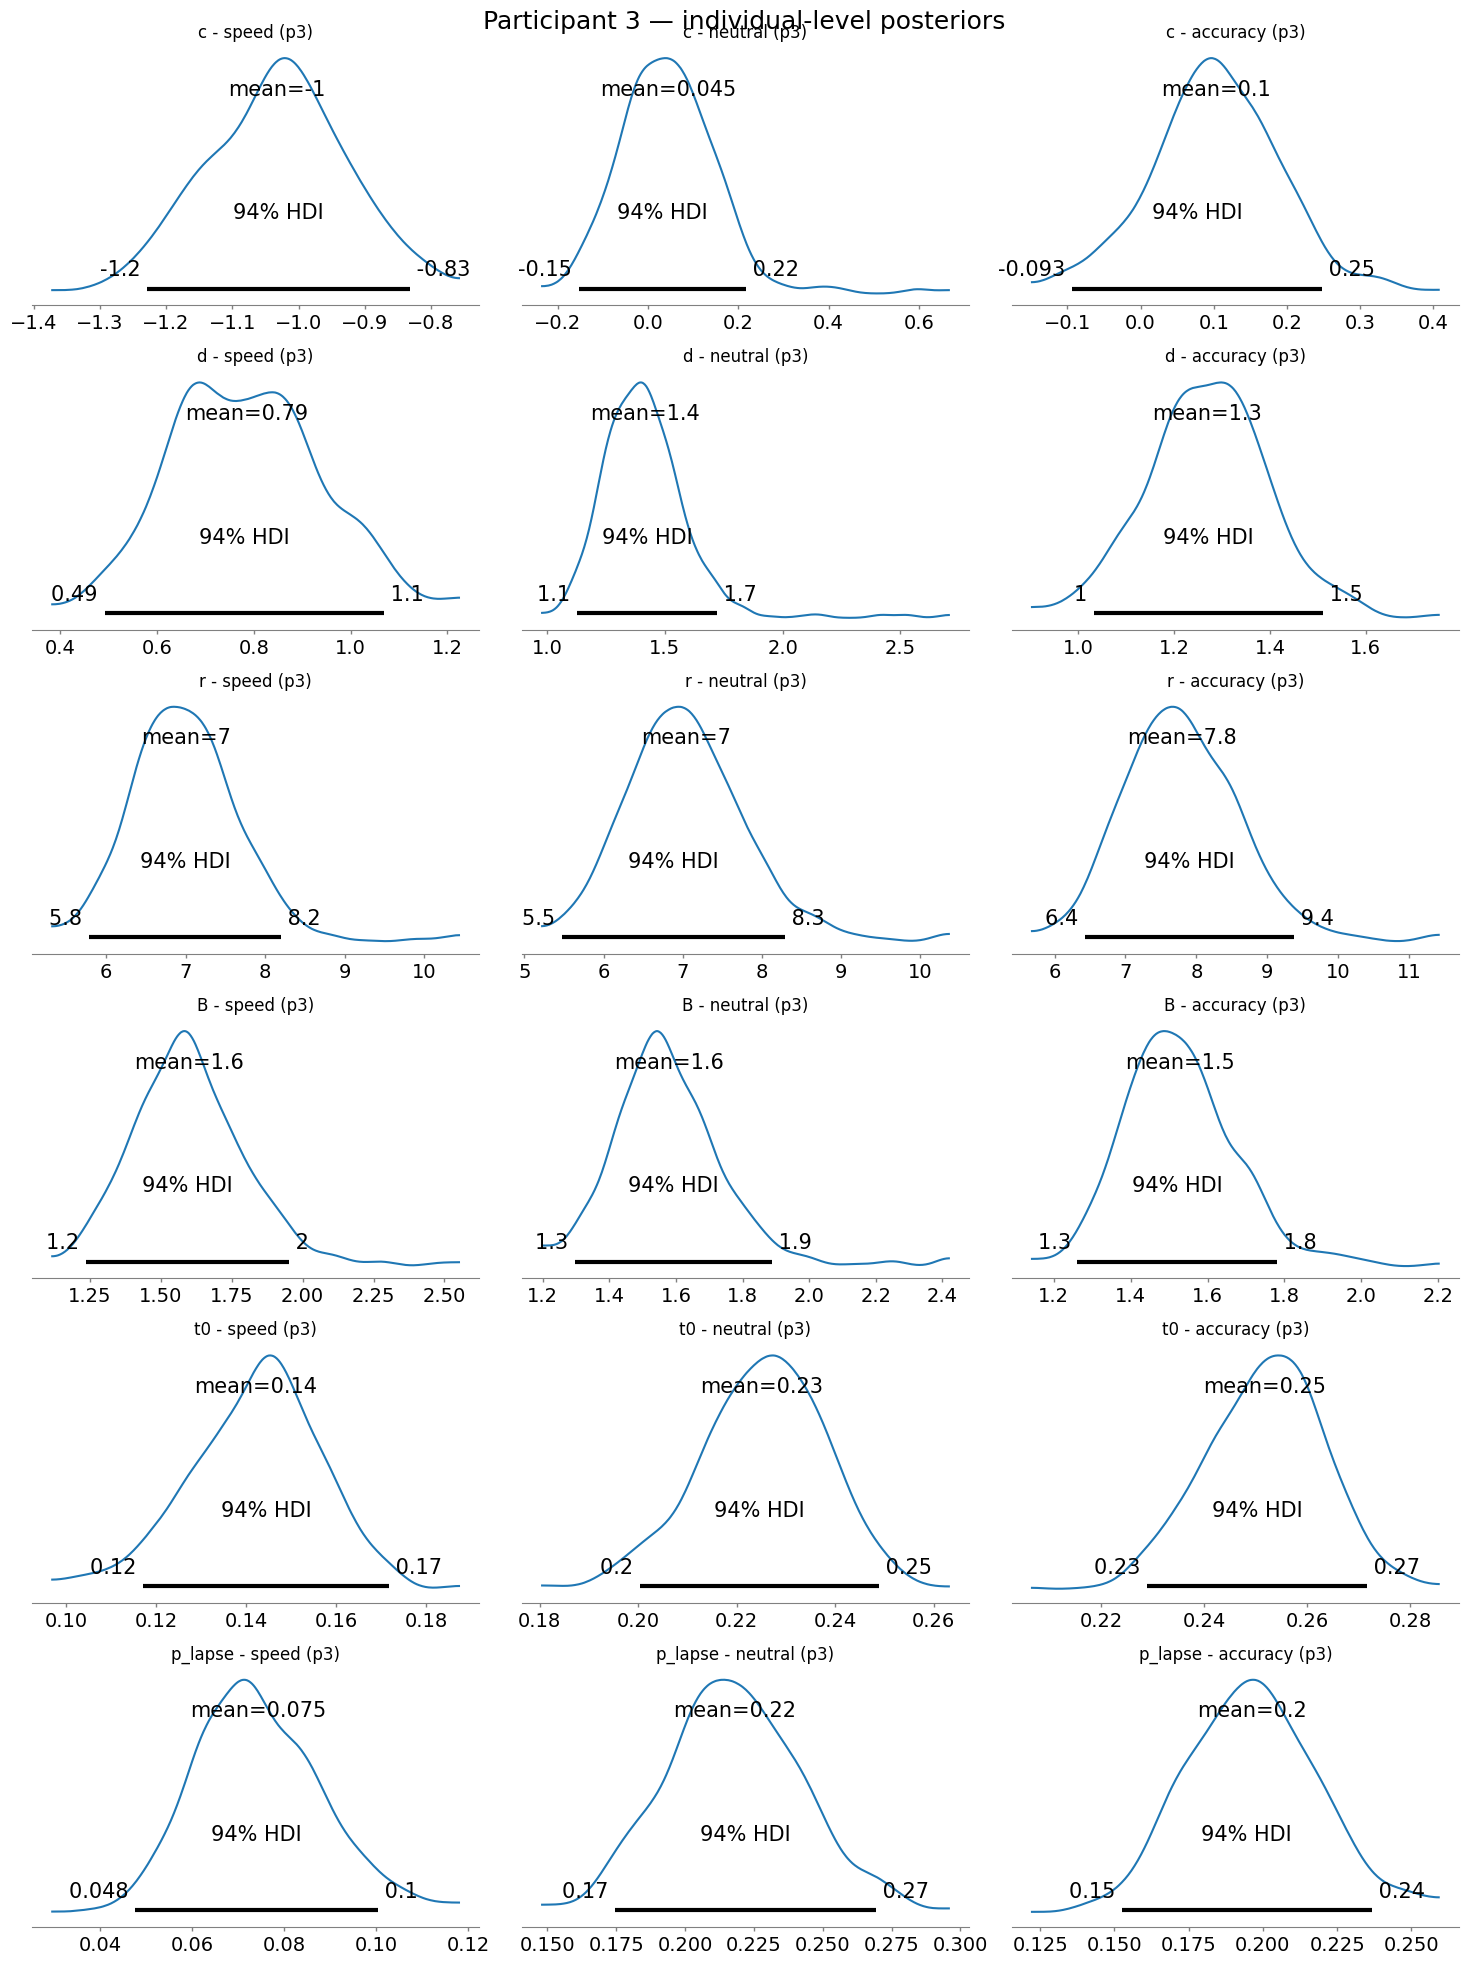

KeyError: 'Coords should follow mapping format {coord_name:[dim1, dim2]}. Check that coords structure is correct and dimensions are valid. "not all values found in index \'r_dim_0\'"'

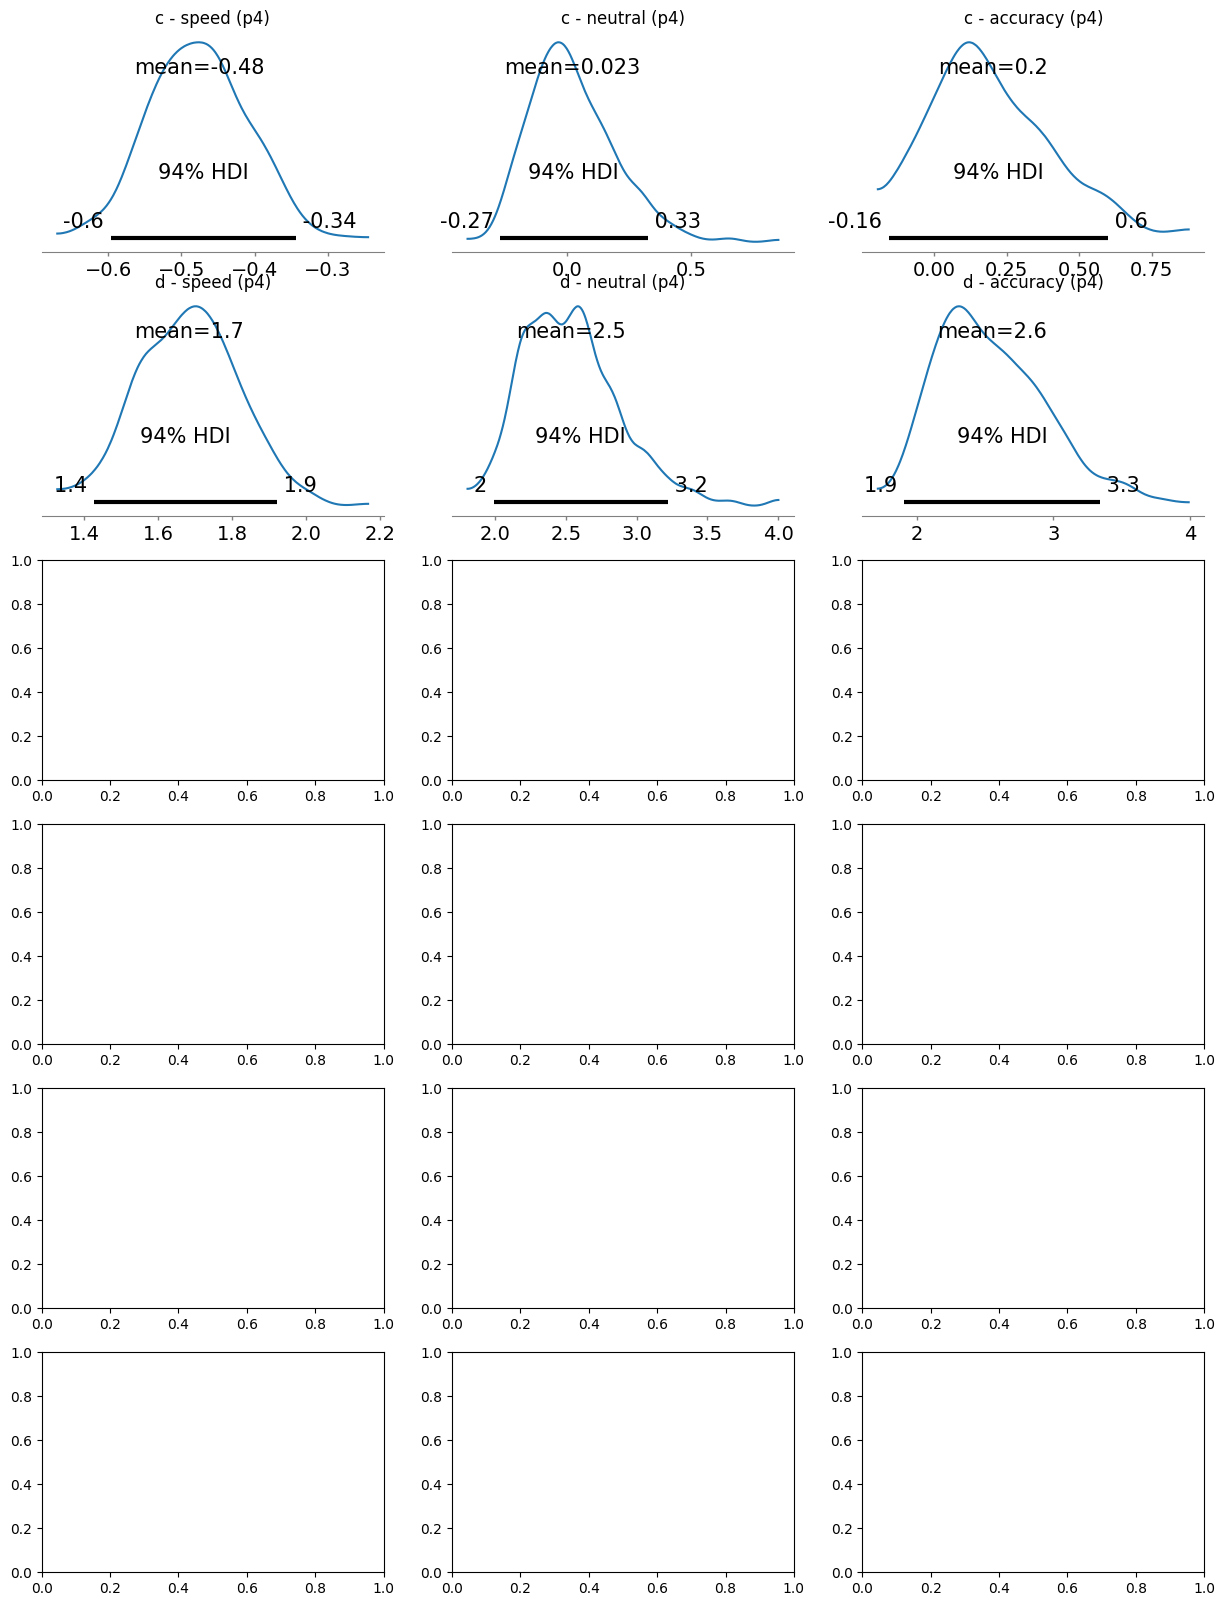

In [ ]:
n_participants = 19
per_cell_vars = ["c", "d", "r", "B", "t0", "p_lapse"]  # all 3*P now, no separate scalar group

for p in range(n_participants):
    fig, axes = plt.subplots(6, 3, figsize=(15, 20))
    idx = [p*3, p*3+1, p*3+2]

    for row, var in enumerate(per_cell_vars):
        dim = f"{var}_dim_0"
        for j, cond in enumerate(cond_labels):
            az.plot_posterior(idata, var_names=[var], coords={dim: [idx[j]]}, ax=axes[row, j])
            axes[row, j].set_title(f"{var} - {cond} (p{p+1})")

    fig.suptitle(f"Participant {p+1} — individual-level posteriors", fontsize=18)
    plt.tight_layout()
    plt.show()